In [18]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


In [19]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


### Task 1

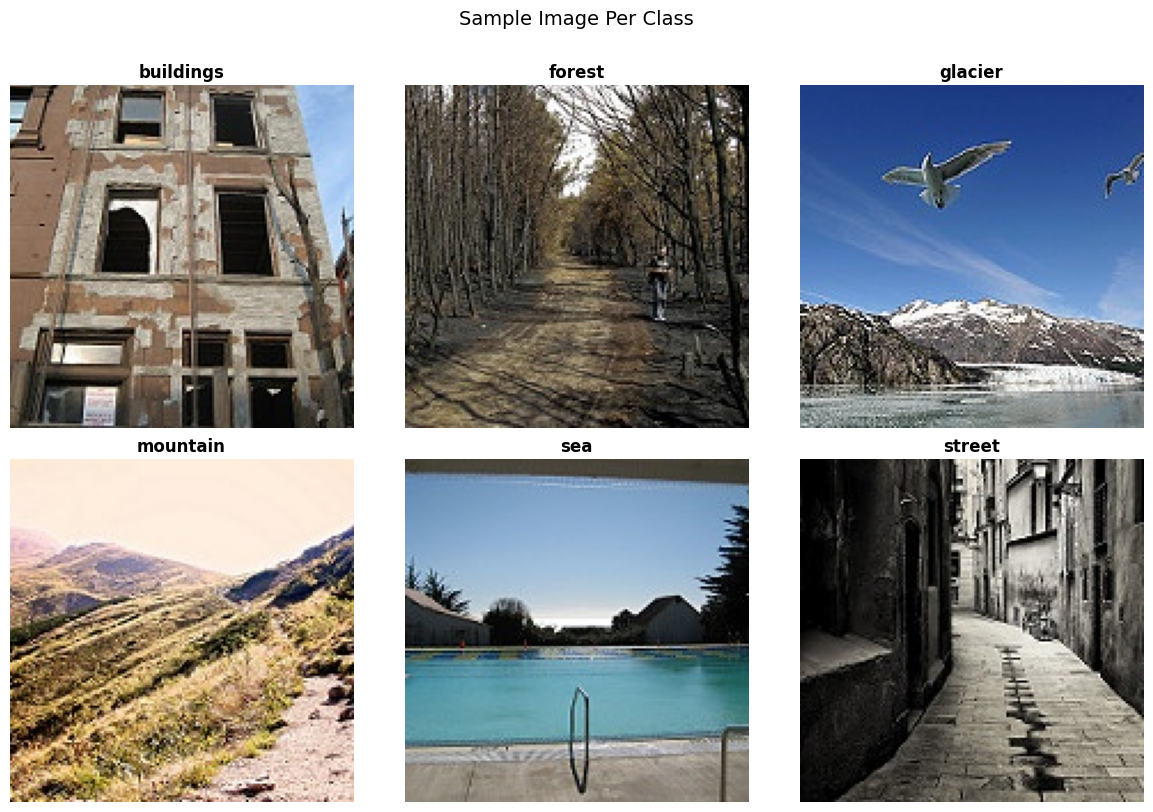

In [20]:
samples = {}
for img, label in image_set:
    if label not in samples:
        samples[label] = img
    if len(samples) == len(LABELS):
        break

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle("Sample Image Per Class", fontsize=14, y=1.01)

for ax, label in zip(axes.flat, LABELS):
    ax.imshow(samples[label])
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("/assignment_04/outputs/dataset_sample.png", bbox_inches="tight")
plt.show()

This is a reasonable starting point because the previous data set has labels and categories with a comparable features. Some labels are a 1-to-1 match which means the models is well trained on them while others are not as similar but still have commonalities with the types of images the original model is trained with. It landscapes vs landscapes, it not like ImageNet is trying to identify human faces or animals.

###  Task 2

In [21]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [22]:
def run_inference(model, preproc, pil_image, device, class_labels, top_k=5):
    """
    Run a single forward pass and return top-k predictions.

    Parameters
    ----------
    model       : nn.Module  — already on device, in eval mode
    preproc     : callable   — torchvision preprocessing pipeline
    pil_image   : PIL.Image
    device      : torch.device
    class_labels: list[str]  — ordered list matching model output indices
    top_k       : int        — how many predictions to return

    Returns
    -------
    list of (class_name, probability) tuples, highest probability first
    """
    tensor = preproc(pil_image).unsqueeze(0).to(device)   

    with torch.no_grad():
        logits = model(tensor)                             
        probs  = torch.softmax(logits, dim=1)[0]           

    top_k_probs, top_k_indices = torch.topk(probs, k=top_k)

    return [
        (class_labels[idx.item()], prob.item())
        for prob, idx in zip(top_k_probs, top_k_indices)
    ]

In [23]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


Mean probability by class:
  buildings   : 0.289
  forest      : 0.248
  glacier     : 0.499
  mountain    : 0.556
  sea         : 0.571
  street      : 0.354


/tmp/ipykernel_57/3821378538.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(class_data, labels=LABELS)


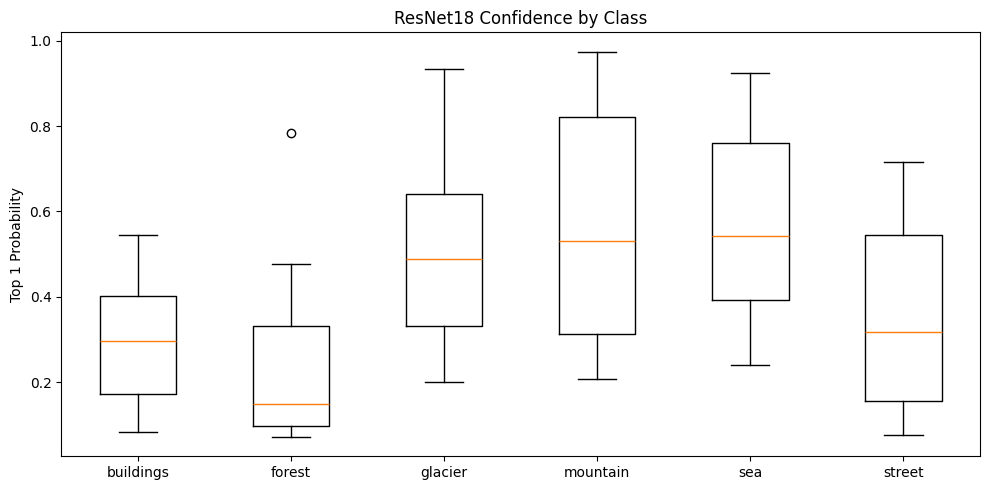

In [24]:


print("Mean probability by class:")
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    print(f"  {label:12s}: {sum(probs)/len(probs):.3f}")

# Boxplot
fig, ax = plt.subplots(figsize=(10, 5))
class_data = [
    [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    for label in LABELS
]
ax.boxplot(class_data, labels=LABELS)
ax.set_title("ResNet18 Confidence by Class")
ax.set_ylabel("Top 1 Probability")

plt.tight_layout()
plt.savefig("/assignment_04/outputs/resnet18_confidence_by_class.png", bbox_inches="tight")
plt.show()

I would use the confidence score to decide how reliable a model is at predicting that category of image. For example the model has generally low performance with buildings and forest, that would indicate--more training needs to be done or this is not the right pretrained for for this category of image. 

In general, I would say a boxplot confidence score that all fall under 50% should be flagged for human reviewer because that means the model is doing worse than chance.

### Task 3

In [25]:
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


In [26]:
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"MobileNet results:  {len(mobilenet_results)}")
print(f"EfficientNet results: {len(effnet_results)}")

MobileNet results:  60
EfficientNet results: 60


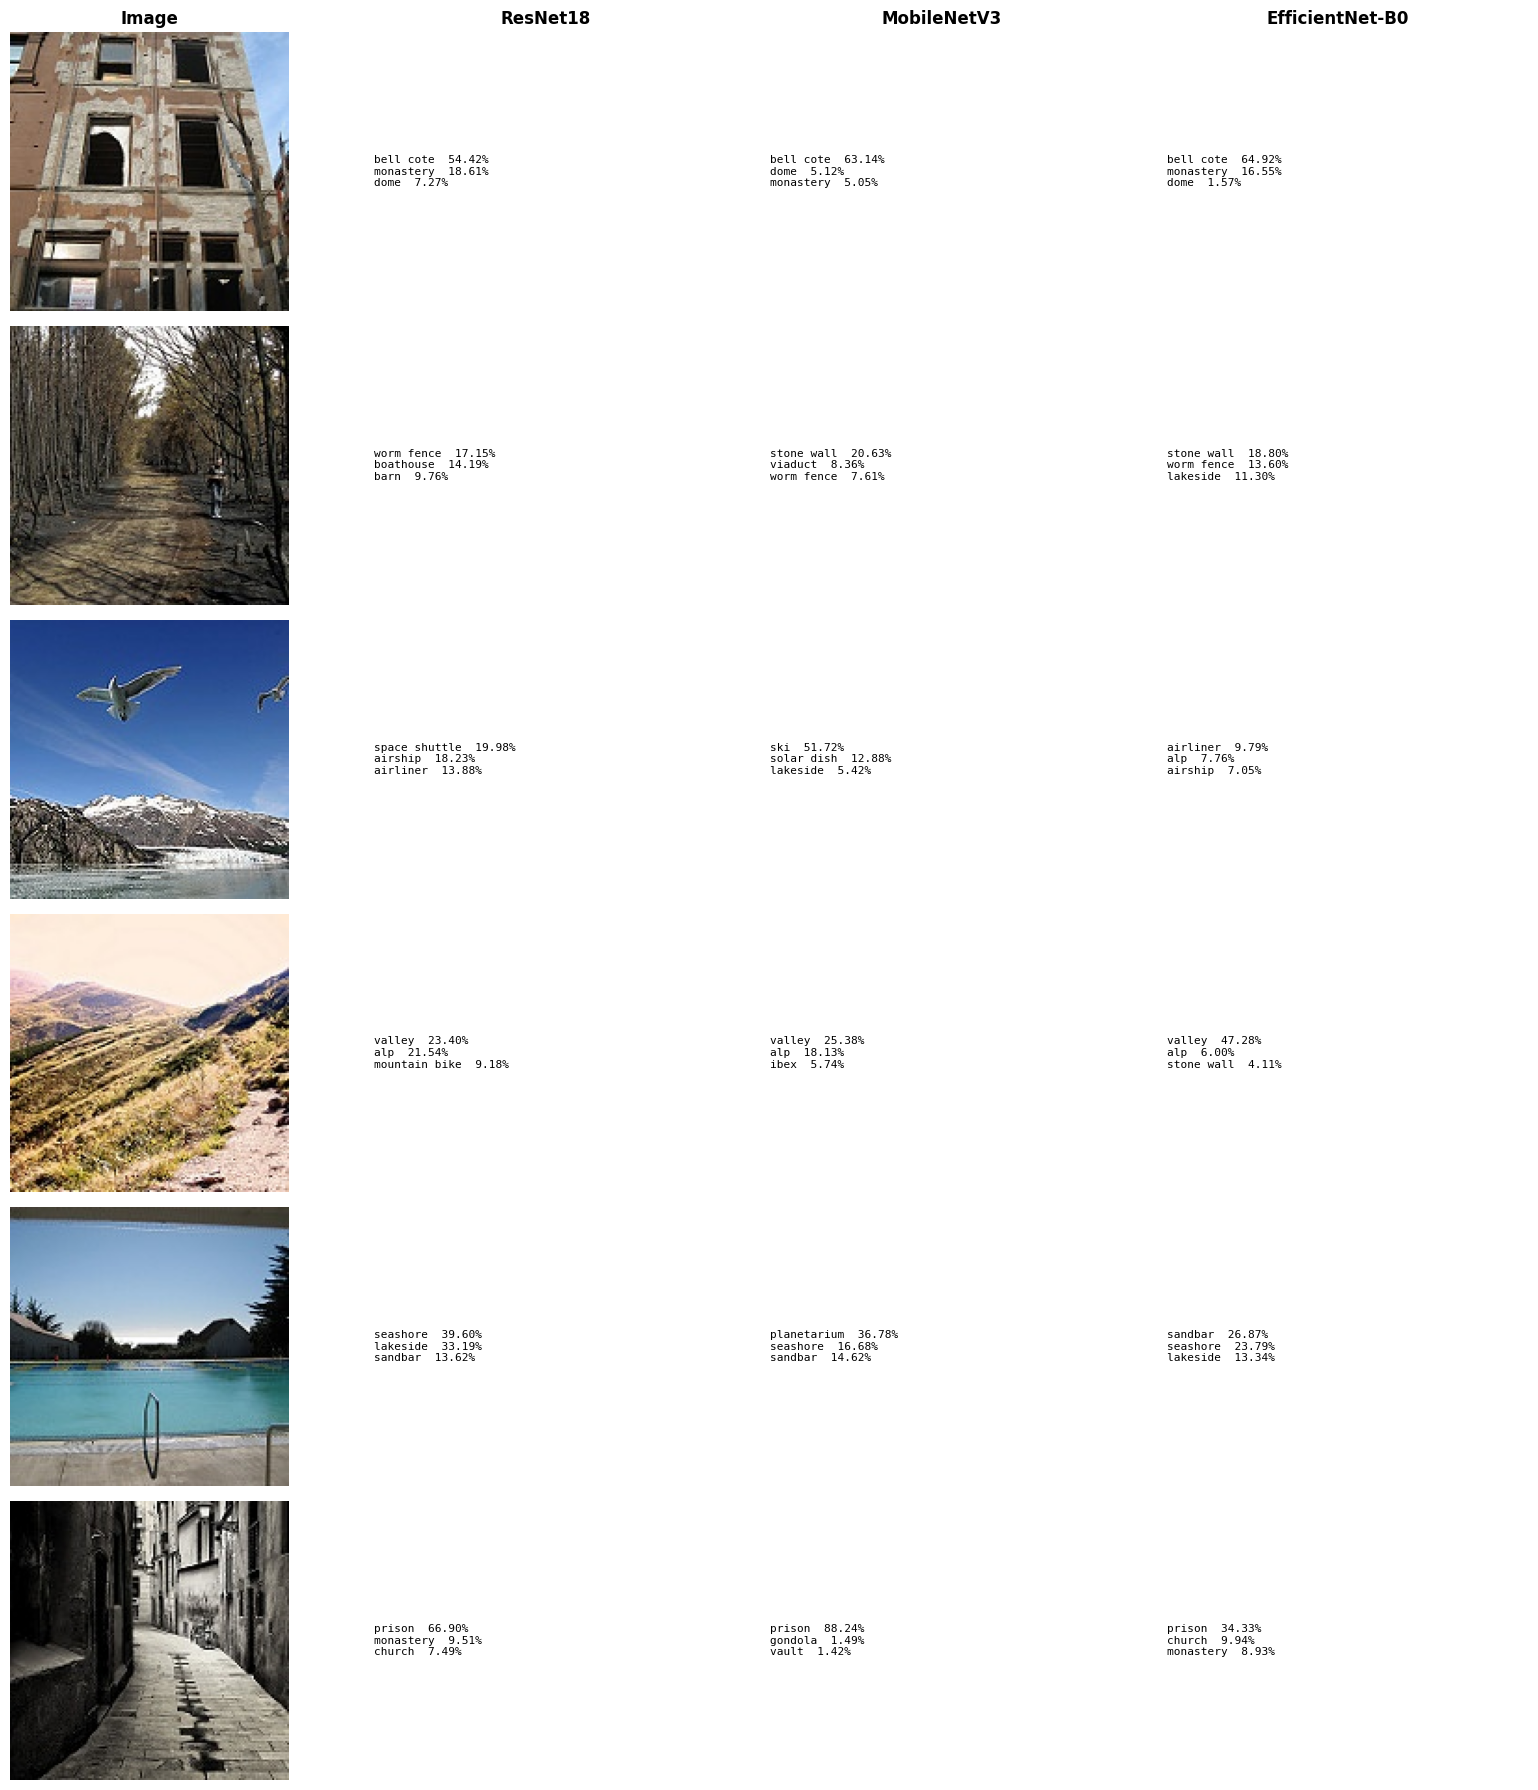

In [27]:
samples = {}
for i, (img, label) in enumerate(image_set):
    if label not in samples:
        samples[label] = i
    if len(samples) == len(LABELS):
        break

MODEL_NAMES = ["ResNet18", "MobileNetV3", "EfficientNet-B0"]
all_results = [resnet_results, mobilenet_results, effnet_results]

fig, axes = plt.subplots(len(LABELS), 4, figsize=(16, 3 * len(LABELS)))

for col, title in enumerate(["Image"] + MODEL_NAMES):
    axes[0, col].set_title(title, fontweight="bold")

for row, label in enumerate(LABELS):
    idx = samples[label]
    img, _ = image_set[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(label, fontweight="bold", rotation=0, labelpad=60, va="center")
    axes[row, 0].axis("off")

    for col, results in enumerate(all_results, start=1):
        r = results[idx]
        text = "\n".join(f"{r['top5_classes'][k][:28]}  {r['top5_probs'][k]:.2%}" for k in range(3))
        axes[row, col].text(0.05, 0.5, text, transform=axes[row, col].transAxes, fontsize=8, va="center", family="monospace")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("/assignment_04/outputs/model_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()

1. They agreed on their #1 prediction on 50% of the images
2. Yes, they disagreed significantly on the pool, and they were all wrong. In that instance, I do not think combining prediction models would inherently make the prediction more accurate but rather add extra noise
3. Efficient net made the most sense semantically, but very low confidence in the categories that all of the models performed poorly in, so that is good

### Task 4

In [28]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    start = time.time()
    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)
    torch.cuda.synchronize()
    elapsed = time.time() - start
    return (elapsed / len(image_set)) * 1000

resnet_ms = benchmark_model(resnet,       resnet_preproc, image_set, device)
mobile_ms = benchmark_model(mobilenet,    mobile_preproc, image_set, device)
effnet_ms = benchmark_model(efficientnet, effnet_preproc, image_set, device)

print(f"ResNet18:          {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small: {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:   {effnet_ms:.2f} ms/image")

ResNet18:          4.08 ms/image
MobileNetV3-Small: 6.60 ms/image
EfficientNet-B0:   9.48 ms/image


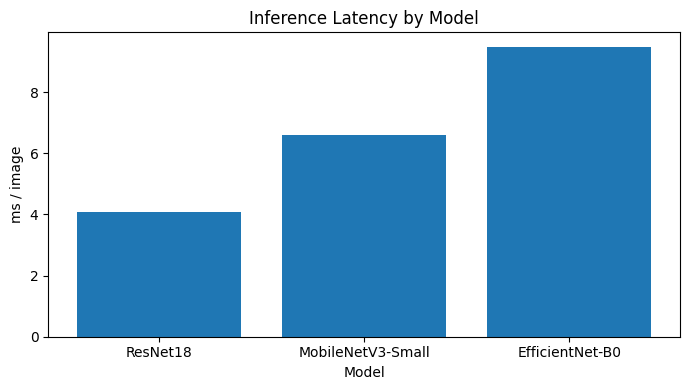

In [29]:
names     = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, latencies)
ax.set_title("Inference Latency by Model")
ax.set_ylabel("ms / image")
ax.set_xlabel("Model")
plt.tight_layout()
plt.savefig("/assignment_04/outputs/inference_speed.png", dpi=150, bbox_inches="tight")
plt.show()


In [30]:
models_info = [
    ("ResNet18",          resnet,       resnet_ms),
    ("MobileNetV3-Small", mobilenet,    mobile_ms),
    ("EfficientNet-B0",   efficientnet, effnet_ms),
]

print(f"{'Model':<22} {'Parameters':>12}  {'ms/image':>10}")
print("-" * 48)
for name, model, ms in models_info:
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:<22} {params:>12,}  {ms:>10.2f}")

Model                    Parameters    ms/image
------------------------------------------------
ResNet18                 11,689,512        4.08
MobileNetV3-Small         2,542,856        6.60
EfficientNet-B0           5,288,548        9.48


1. All of the models can do more than 50 images per second, ResNet 18 is the fastest. The max tolerable latency per image would be 20 ms per image
2. I would probably do the mobilenet for the mix of usability on a model phone and the speed

### Task 5

In [31]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")

Feature matrix shape: (60, 512)


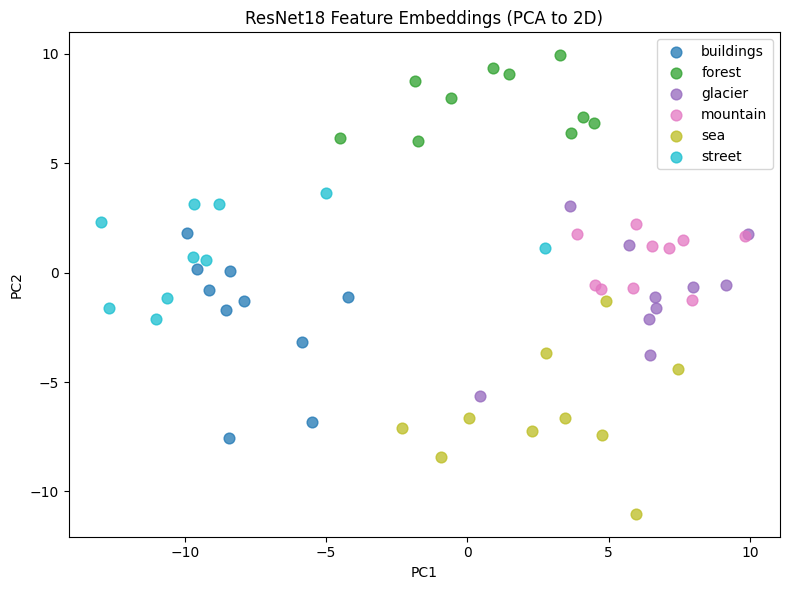

In [32]:
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("/assignment_04/outputs/feature_embeddings.png")
plt.show()

1. Yes they are generally generally in the same quadrant. This means the pretrained models have built a certain correlation to features
2. Start with feature extraction would probably be best since the sample size is so small, it is not enough to fine tune a model

### Task 6
* Based on speed and semantic accuracy EfficientNet performed the best
* Most confident about the mountain and least confident about the forest and that matches the results in the image analysis
* I would suggest starting with EfficientNet, since in the catergories that it was wrong, it had low confidence, which I think is a good sign for training and learning. There would need to be additional feature detection since the categories the model did the worst on there was a lack of training. One limitation would be the lack of accuracy when it comes to animals and with the pool. So any non natural landscape will not have the best results.